## 0. Imports & Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

In [ ]:
DATA_DIR = Path("/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data")

In [ ]:
FILES = {
    "egg_price":             DATA_DIR / "APU0000708111.csv",
    "layers_on_hand":        DATA_DIR / "USDA_NASS_LayersOnHand_1974_Present.csv",
    "egg_production":        DATA_DIR / "egg_production_usda.csv",
    "rate_of_lay":           DATA_DIR / "USDA_NASS_RateOfLayPer100_2007_Present.csv",
    "layers_loss":           DATA_DIR / "layers_loss_usda.csv",
    "hpai_confirmed_cases":  DATA_DIR / "HPAI_Confirmed_Cases_in_Commercial_and_Backyard_Flocks.csv",
    "hpai_confirmation_table": DATA_DIR / "USDA_APHIS_HPAI_2022_A Table by Confirmation Date.csv",
    "hpai_affected_totals":  DATA_DIR / "USDA_APHIS_HPAI_2022_Affected Totals.csv",
    "hpai_affected_totals_data": DATA_DIR / "Affected Totals_data.csv",
    "hpai_birds_monthly":    DATA_DIR / "hpai_birds_monthly.csv",
    "historical_outbreaks":  DATA_DIR / "historical_outbreaks.csv",
}

## 1. Helper Functions

In [ ]:
MONTH_MAP = {
    "JAN": 1, "FEB": 2, "MAR": 3, "APR": 4, "MAY": 5,  "JUN": 6,
    "JUL": 7, "AUG": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12,
}

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )

def parse_nass_monthly(df: pd.DataFrame) -> pd.DataFrame:
    """
    Parse USDA NASS monthly files whose Period column may read:
      'JAN', 'FIRST OF JAN', 'END OF DEC', etc.
    Returns the original columns plus: date, value_num.
    """
    out = df.copy()
    out["Period"] = out["Period"].astype(str).str.strip().str.upper()
    out["Year"]   = pd.to_numeric(out["Year"], errors="coerce")

    month_pattern     = r"(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)"
    out["month_abbr"] = out["Period"].str.extract(month_pattern, expand=False)
    out["month_num"]  = out["month_abbr"].map(MONTH_MAP)
    out["date"]       = pd.to_datetime(
        {"year": out["Year"], "month": out["month_num"], "day": 1}, errors="coerce"
    )
    out["value_num"]  = clean_numeric(out["Value"])
    return out.dropna(subset=["date", "value_num"]).copy()

def monthly_sum(df: pd.DataFrame, date_col: str, value_col: str, out_name: str) -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col])
    out["month"]   = out[date_col].dt.to_period("M").dt.to_timestamp()
    out[value_col] = clean_numeric(out[value_col])
    return (
        out.groupby("month", as_index=False)[value_col]
           .sum(min_count=1)
           .rename(columns={value_col: out_name})
    )

def monthly_count(df: pd.DataFrame, date_col: str, out_name: str) -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col])
    out["month"] = out[date_col].dt.to_period("M").dt.to_timestamp()
    return (
        out.groupby("month", as_index=False)
           .size()
           .rename(columns={"size": out_name})
    )


## 2. Egg Price (Target Alignment Series)
*Source: `APU0000708111.csv`*

In [ ]:
egg = pd.read_csv(FILES["egg_price"], parse_dates=["observation_date"])
egg = egg.rename(columns={"observation_date": "month", "APU0000708111": "egg_price"})
egg = egg[["month", "egg_price"]].copy()
egg["egg_price"]     = pd.to_numeric(egg["egg_price"], errors="coerce")
egg                   = egg.dropna().sort_values("month").drop_duplicates("month")
egg["log_egg_price"] = np.log(egg["egg_price"])
print(egg.head())

       month  egg_price  log_egg_price
0 1980-01-01      0.879      -0.128970
1 1980-02-01      0.774      -0.256183
2 1980-03-01      0.812      -0.208255
3 1980-04-01      0.797      -0.226901
4 1980-05-01      0.737      -0.305167


In [ ]:
print("Contents of DATA_DIR:")
for item in DATA_DIR.iterdir():
    print(item.name)

Contents of DATA_DIR:
APU0000708111.csv
layers_loss_usda.csv
egg_production_usda.csv
HPAI_Confirmed_Cases_in_Commercial_and_Backyard_Flocks.csv
Affected Totals_data.csv
USDA_APHIS_HPAI_2022_A Table by Confirmation Date.csv
USDA_APHIS_HPAI_2022_Affected Totals.csv
hpai_birds_monthly.csv
historical_outbreaks.csv
USDA_NASS_LayersOnHand_1974_Present.csv
.ipynb_checkpoints
USDA_NASS_RateOfLayPer100_2007_Present.csv
avian_flu_master_dataset.csv
avian_flu_historical_panel.csv
avian_flu_proxy_panel.csv
avian_flu_proxy_panel_main_2013plus.csv
avian_flu_direct_panel.csv
avian_flu_predictive_residuals.csv
avian_flu_residual_panel.csv
avian_flu_master_dataset.gsheet


## 3. NASS: Layers on Hand
*Source: `USDA_NASS_LayersOnHand_1974_...csv` — national US total only*

In [ ]:
layers_raw = pd.read_csv(FILES["layers_on_hand"], low_memory=False)
layers     = parse_nass_monthly(layers_raw)

print("--- Raw columns ---")
print(layers_raw.columns.tolist())

# Keep national rows only
geo_mask = pd.Series(True, index=layers.index)
if "Geo Level" in layers.columns:
    geo_mask &= layers["Geo Level"].astype(str).str.upper().eq("NATIONAL")
if "State" in layers.columns:
    geo_mask &= layers["State"].astype(str).str.upper().eq("US TOTAL")
layers = layers[geo_mask].copy()

print("\n--- Candidate Data Item values ---")
if "Data Item" in layers.columns:
    print(layers["Data Item"].dropna().astype(str).value_counts().head(20))

# Flexible pattern filter
candidate_mask = pd.Series(False, index=layers.index)
if "Data Item" in layers.columns:
    di = layers["Data Item"].astype(str)
    candidate_mask |= di.str.contains("LAYERS",    case=False, na=False)
    candidate_mask |= di.str.contains("ON HAND",   case=False, na=False)
    candidate_mask |= di.str.contains("INVENTORY", case=False, na=False)

layers_filtered = layers[candidate_mask].copy()
if layers_filtered.empty:
    print("\nWARNING: No rows matched; keeping all national rows for inspection.")
    layers_filtered = layers.copy()

layers = (
    layers_filtered[["date", "value_num"]]
    .rename(columns={"date": "month", "value_num": "layers_on_hand"})
    .sort_values("month")
    .drop_duplicates("month")
)
print("\nParsed layers_on_hand preview:")
print(layers.head(), "\nRows:", len(layers))


--- Raw columns ---
['Program', 'Year', 'Period', 'Week Ending', 'Geo Level', 'State', 'State ANSI', 'Ag District', 'Ag District Code', 'County', 'County ANSI', 'Zip Code', 'Region', 'watershed_code', 'Watershed', 'Commodity', 'Data Item', 'Domain', 'Domain Category', 'Value', 'CV (%)']

--- Candidate Data Item values ---
Data Item
CHICKENS, LAYERS - INVENTORY    225
Name: count, dtype: int64

Parsed layers_on_hand preview:
           month  layers_on_hand
18503 1997-12-01     314144304.0
15450 2002-12-01     334435155.0
12415 2007-12-01     349772508.0
22591 2008-01-01     345699000.0
22590 2008-02-01     344079000.0 
Rows: 222


## 4. NASS: Egg Production
*Source: `egg_production_usda.csv` — prefers table-egg series; falls back to total*

In [ ]:
egg_prod = pd.read_csv(FILES["egg_production"], low_memory=False)
egg_prod = parse_nass_monthly(egg_prod)
egg_prod = egg_prod[
    (egg_prod["Geo Level"].astype(str).str.upper() == "NATIONAL") &
    (egg_prod["State"].astype(str).str.upper()     == "US TOTAL")
].copy()

table_mask = egg_prod["Data Item"].astype(str).str.contains("TABLE - PRODUCTION",    case=False, na=False)
total_mask = egg_prod["Data Item"].astype(str).str.contains(r"\bEGGS - PRODUCTION\b", case=False, na=False)

source         = egg_prod[table_mask] if len(egg_prod[table_mask]) > 0 else egg_prod[total_mask]
egg_prod_final = (
    source[["date", "value_num"]]
    .rename(columns={"date": "month", "value_num": "egg_production_dozen"})
    .sort_values("month")
    .drop_duplicates("month")
)


## 5. NASS: Rate of Lay
*Source: `USDA_NASS_RateOfLayPer100_2007_...csv`*

In [ ]:
rol = pd.read_csv(FILES["rate_of_lay"], low_memory=False)
rol = parse_nass_monthly(rol)
rol = rol[
    (rol["Geo Level"].astype(str).str.upper() == "NATIONAL") &
    (rol["State"].astype(str).str.upper()     == "US TOTAL") &
    rol["Data Item"].astype(str).str.contains("RATE OF LAY", case=False, na=False)
].copy()
rol = (
    rol[["date", "value_num"]]
    .rename(columns={"date": "month", "value_num": "rate_of_lay_per_100"})
    .sort_values("month")
    .drop_duplicates("month")
)


## 6. NASS: Layer Losses
*Source: `layers_loss_usda.csv`*

In [ ]:
loss = pd.read_csv(FILES["layers_loss"], low_memory=False)
loss = parse_nass_monthly(loss)
loss = loss[
    (loss["Geo Level"].astype(str).str.upper() == "NATIONAL") &
    (loss["State"].astype(str).str.upper()     == "US TOTAL") &
    loss["Data Item"].astype(str).str.contains("LOSS, DEATH & RENDERED", case=False, na=False)
].copy()
loss = (
    loss[["date", "value_num"]]
    .rename(columns={"date": "month", "value_num": "layer_losses_head"})
    .sort_values("month")
    .drop_duplicates("month")
)


## 7. APHIS: Confirmed HPAI Cases
*Source: `HPAI_Confirmed_Cases...csv` (UTF-16 TSV)*

In [ ]:
hpai_cases_raw = pd.read_csv(
    FILES["hpai_confirmed_cases"],
    encoding="utf-16", sep="\t", header=None, low_memory=False,
)

# Row 1 holds real column names; make them unique
base_cols = hpai_cases_raw.iloc[1].astype(str).str.strip().tolist()
seen, new_cols = {}, []
for c in base_cols:
    if c in seen:
        seen[c] += 1
        new_cols.append(f"{c}_{seen[c]}")
    else:
        seen[c] = 0
        new_cols.append(c)

hpai_cases = hpai_cases_raw.iloc[2:].copy()
hpai_cases.columns = new_cols
hpai_cases = hpai_cases.reset_index(drop=True)

hpai_cases["Confirmed"] = pd.to_datetime(hpai_cases["Confirmed"], errors="coerce")
hpai_cases = hpai_cases.dropna(subset=["Confirmed"]).rename(columns={
    "Confirmed":   "confirmed_date",
    "State":       "state",
    "County Name": "county_name",
    "Special Id":  "special_id",
    "Production":  "production",
})

def _monthly_detections(df, prod_filter, out_col):
    subset = (
        df[df["production"].astype(str).str.contains(prod_filter, case=False, na=False)]
        if prod_filter else df
    )
    return (
        subset
        .assign(month=subset["confirmed_date"].dt.to_period("M").dt.to_timestamp())
        .groupby("month", as_index=False)
        .size()
        .rename(columns={"size": out_col})
    )

hpai_monthly_counts     = _monthly_detections(hpai_cases, None,                           "hpai_detection_count")
hpai_monthly_commercial = _monthly_detections(hpai_cases, "Commercial|WOAH Poultry",      "hpai_commercial_detection_count")
hpai_monthly_layerlike  = _monthly_detections(hpai_cases, "Table Egg|Layer|Breeder Hens", "hpai_layerlike_detection_count")

print(hpai_cases[["confirmed_date", "state", "county_name", "production"]].head())
print(hpai_monthly_counts.head())


  confirmed_date         state   county_name                        production
0     2025-05-13  South Dakota    Hutchinson       Commercial Turkey Meat Bird
1     2025-05-12    New Jersey         Essex                  Live Bird Market
2     2025-05-09      Maryland  Anne Arundel                  WOAH Non-Poultry
3     2025-05-08       Florida    Miami-dade  Live Bird Sales  (non-slaughter)
4     2025-05-05  North Dakota        Kidder                      WOAH Poultry
       month  hpai_detection_count
0 2022-02-01                    15
1 2022-03-01                    87
2 2022-04-01                   166
3 2022-05-01                    89
4 2022-06-01                    22


/tmp/ipykernel_4712/500620799.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hpai_cases["Confirmed"] = pd.to_datetime(hpai_cases["Confirmed"], errors="coerce")


## 8. APHIS: Monthly Birds Affected
*Source: `hpai_birds_monthly.csv` — wide format; row 0 = month labels, `False` row = completed-month totals*

In [ ]:
hpai_birds_path = DATA_DIR / "hpai_birds_monthly.csv"

if hpai_birds_path.exists():
    try:
        hpai_birds_raw = pd.read_csv(hpai_birds_path)
    except UnicodeDecodeError:
        try:
            hpai_birds_raw = pd.read_csv(hpai_birds_path, encoding="utf-16", sep="\t")
        except Exception:
            hpai_birds_raw = pd.read_csv(hpai_birds_path, encoding="utf-16")

    hpai_birds_raw.columns = [str(c).strip() for c in hpai_birds_raw.columns]
    print("hpai_birds_monthly raw:\n", hpai_birds_raw.head())

    first_col      = hpai_birds_raw.columns[0]
    hpai_birds_raw = hpai_birds_raw.rename(columns={first_col: "is_last_reporting_month"})
    month_label_row = hpai_birds_raw.iloc[0]

    false_rows = hpai_birds_raw[
        hpai_birds_raw["is_last_reporting_month"].astype(str).str.strip().str.lower() == "false"
    ]
    if false_rows.empty:
        raise ValueError("Could not find the completed-month row (False) in hpai_birds_monthly.csv")
    hpai_birds_row = false_rows.iloc[0]

    records = []
    for col in hpai_birds_raw.columns[1:]:
        month_label = str(month_label_row[col]).strip()
        raw_val     = str(hpai_birds_row[col]).strip()
        if not month_label or month_label.lower() == "nan": continue
        if not raw_val     or raw_val.lower()     == "nan": continue

        month      = pd.to_datetime(month_label, format="%b %Y", errors="coerce")
        val        = raw_val.replace(",", "").upper()
        multiplier = 1
        if val.endswith("M"):   multiplier, val = 1_000_000, val[:-1]
        elif val.endswith("K"): multiplier, val = 1_000,     val[:-1]

        birds = pd.to_numeric(val, errors="coerce")
        if pd.notna(month) and pd.notna(birds):
            records.append({"month": month, "hpai_birds_affected": birds * multiplier})

    hpai_birds = (
        pd.DataFrame(records).sort_values("month").reset_index(drop=True)
        if records else pd.DataFrame(columns=["month", "hpai_birds_affected"])
    )
else:
    hpai_birds = pd.DataFrame(columns=["month", "hpai_birds_affected"])

print("\nParsed hpai_birds:\n", hpai_birds)


hpai_birds_monthly raw:
                 Unnamed: 0 Birds Affected Birds Affected.1 Birds Affected.2  \
0  Is Last Reporting Month       Jan 2026         Feb 2026         Mar 2026   
1                    False          4.05M           11.41M            5.27M   
2                     True            NaN              NaN              NaN   

  Birds Affected.3  
0         Apr 2026  
1              NaN  
2            0.49M  

Parsed hpai_birds:
        month  hpai_birds_affected
0 2026-01-01            4050000.0
1 2026-02-01           11410000.0
2 2026-03-01            5270000.0


## 9. Manual Historical Outbreak Series
*Source: `historical_outbreaks.csv` (user-created) — expected columns: `month`, `outbreak_dummy`, `severity_score`, `notes`*

In [ ]:
if FILES["historical_outbreaks"].exists():
    hist = pd.read_csv(FILES["historical_outbreaks"])
    hist["month"]          = pd.to_datetime(hist["month"], errors="coerce")
    hist["outbreak_dummy"] = pd.to_numeric(hist["outbreak_dummy"], errors="coerce").fillna(0)
    hist["severity_score"] = pd.to_numeric(hist["severity_score"], errors="coerce").fillna(0)

    keep_cols = ["month", "outbreak_dummy", "severity_score"]
    if "notes" in hist.columns:
        keep_cols.append("notes")
    hist = hist[keep_cols].dropna(subset=["month"]).sort_values("month")
else:
    hist = pd.DataFrame(columns=["month", "outbreak_dummy", "severity_score", "notes"])


## 10. Merge into Master Dataset

In [ ]:
master = egg.copy()

for addon in [
    layers, egg_prod_final, rol, loss,
    hpai_monthly_counts, hpai_monthly_commercial, hpai_monthly_layerlike,
    hpai_birds, hist,
]:
    if len(addon) > 0:
        master = master.merge(addon, on="month", how="left")


## 11. Feature Engineering

In [ ]:
# Normalised loss rate
master["layer_loss_rate"] = master["layer_losses_head"] / master["layers_on_hand"]

# Log-transform supply-side variables
for col in ["layers_on_hand", "egg_production_dozen", "rate_of_lay_per_100"]:
    if col in master.columns:
        master[f"log_{col}"] = np.where(master[col] > 0, np.log(master[col]), np.nan)

# Log birds affected
if "hpai_birds_affected" in master.columns:
    master["log_hpai_birds_affected_plus1"] = np.log1p(master["hpai_birds_affected"])
else:
    master["log_hpai_birds_affected_plus1"] = np.nan

# Combined avian-flu intensity score
master["avian_flu_intensity"] = (
    master.get("severity_score", pd.Series(0, index=master.index)).fillna(0)
    + np.log1p(master.get("hpai_commercial_detection_count", pd.Series(0, index=master.index)).fillna(0))
)
if "hpai_birds_affected" in master.columns:
    master["avian_flu_intensity"] += np.log1p(master["hpai_birds_affected"].fillna(0))

# Lags (1–3 months) for attribution analysis
lag_cols = [
    "layer_loss_rate", "layers_on_hand", "egg_production_dozen", "rate_of_lay_per_100",
    "hpai_detection_count", "hpai_commercial_detection_count", "hpai_layerlike_detection_count",
    "hpai_birds_affected", "avian_flu_intensity", "severity_score",
]
for col in lag_cols:
    if col in master.columns:
        for lag in [1, 2, 3]:
            master[f"{col}_lag{lag}"] = master[col].shift(lag)


## 12. Fill Missing Values

In [ ]:
# Outbreak control columns
master["outbreak_dummy"] = master["outbreak_dummy"].fillna(0)
master["severity_score"] = master["severity_score"].fillna(0)
if "notes" in master.columns:
    master["notes"] = master["notes"].fillna("")

# Fill direct HPAI counts as zero only in the modern data era (>= Feb 2022)
direct_cols = [
    "hpai_detection_count", "hpai_commercial_detection_count",
    "hpai_layerlike_detection_count", "hpai_birds_affected",
]
for col in direct_cols:
    if col in master.columns:
        master.loc[master["month"] >= "2022-02-01", col] = (
            master.loc[master["month"] >= "2022-02-01", col].fillna(0)
        )


## 13. QA / Hygiene Checks

In [ ]:
master = master.sort_values("month").drop_duplicates("month").reset_index(drop=True)

print("Master dataset shape:", master.shape)
print("\nColumns:")
print(master.columns.tolist())
print("\nDate range:", master["month"].min(), "to", master["month"].max())
print("\nMissingness summary (top 20):")
print(master.isna().sum().sort_values(ascending=False).head(20))
print("\nPreview:")
print(master.head(12).to_string(index=False))

# Check monthly frequency by year for each NASS series
for name, df_ in [("layers", layers), ("egg_prod", egg_prod_final), ("rol", rol), ("loss", loss)]:
    tmp = df_.copy()
    tmp["year"] = tmp["month"].dt.year
    print(f"\n{name}")
    print(tmp.groupby("year").size().head(15))
    print(tmp.groupby("year").size().tail(10))


Master dataset shape: (553, 50)

Columns:
['month', 'egg_price', 'log_egg_price', 'layers_on_hand', 'egg_production_dozen', 'rate_of_lay_per_100', 'layer_losses_head', 'hpai_detection_count', 'hpai_commercial_detection_count', 'hpai_layerlike_detection_count', 'hpai_birds_affected', 'outbreak_dummy', 'severity_score', 'notes', 'layer_loss_rate', 'log_layers_on_hand', 'log_egg_production_dozen', 'log_rate_of_lay_per_100', 'log_hpai_birds_affected_plus1', 'avian_flu_intensity', 'layer_loss_rate_lag1', 'layer_loss_rate_lag2', 'layer_loss_rate_lag3', 'layers_on_hand_lag1', 'layers_on_hand_lag2', 'layers_on_hand_lag3', 'egg_production_dozen_lag1', 'egg_production_dozen_lag2', 'egg_production_dozen_lag3', 'rate_of_lay_per_100_lag1', 'rate_of_lay_per_100_lag2', 'rate_of_lay_per_100_lag3', 'hpai_detection_count_lag1', 'hpai_detection_count_lag2', 'hpai_detection_count_lag3', 'hpai_commercial_detection_count_lag1', 'hpai_commercial_detection_count_lag2', 'hpai_commercial_detection_count_lag3', 

## 14. Save Outputs

In [ ]:
# Full master dataset
master.to_csv(DATA_DIR / "avian_flu_master_dataset.csv", index=False)
print("Saved: avian_flu_master_dataset.csv")

# Subset panels for different analysis windows
historical_panel = master[["month", "egg_price", "log_egg_price", "outbreak_dummy", "severity_score"]].copy()

proxy_panel = master.loc[
    master["month"] >= "2008-01-01",
    ["month", "egg_price", "log_egg_price", "layers_on_hand", "egg_production_dozen",
     "rate_of_lay_per_100", "layer_losses_head", "layer_loss_rate", "outbreak_dummy", "severity_score"],
].copy()

proxy_panel_main = master.loc[
    master["month"] >= "2013-01-01",
    ["month", "egg_price", "log_egg_price", "layers_on_hand", "egg_production_dozen",
     "rate_of_lay_per_100", "layer_losses_head", "layer_loss_rate", "outbreak_dummy", "severity_score"],
].copy()

direct_panel = master.loc[
    master["month"] >= "2022-02-01",
    ["month", "egg_price", "log_egg_price", "hpai_detection_count",
     "hpai_commercial_detection_count", "hpai_layerlike_detection_count",
     "hpai_birds_affected", "outbreak_dummy", "severity_score"],
].copy()

historical_panel.to_csv(DATA_DIR / "avian_flu_historical_panel.csv",         index=False)
proxy_panel.to_csv(     DATA_DIR / "avian_flu_proxy_panel.csv",               index=False)
proxy_panel_main.to_csv(DATA_DIR / "avian_flu_proxy_panel_main_2013plus.csv", index=False)
direct_panel.to_csv(    DATA_DIR / "avian_flu_direct_panel.csv",              index=False)

print("\nMissingness check - direct panel:")
print(direct_panel.isna().sum())
print(direct_panel.head())
print(direct_panel.tail())


Saved: avian_flu_master_dataset.csv

Missingness check - direct panel:
month                              0
egg_price                          0
log_egg_price                      0
hpai_detection_count               0
hpai_commercial_detection_count    0
hpai_layerlike_detection_count     0
hpai_birds_affected                0
outbreak_dummy                     0
severity_score                     0
dtype: int64
         month  egg_price  log_egg_price  hpai_detection_count  \
505 2022-02-01      2.005       0.695644                  15.0   
506 2022-03-01      2.046       0.715887                  87.0   
507 2022-04-01      2.520       0.924259                 166.0   
508 2022-05-01      2.863       1.051870                  89.0   
509 2022-06-01      2.707       0.995841                  22.0   

     hpai_commercial_detection_count  hpai_layerlike_detection_count  \
505                              8.0                             1.0   
506                             58.0      

## Optional data for v3

There is no clean public USDA APHIS monthly HPAI dataset prior to 2022.
So for direct outbreak intensity, we use the modern APHIS-era data only.

This export creates a simple monthly severity dataset your teammate can merge
into regressions or inference models.

Output columns
--------------
date
    Monthly timestamp (month start). Used as merge key.

hpai_birds_affected
    Total birds affected in that month.
    Source: USDA APHIS affected totals data (2022+), already loaded into master.

log_hpai_intensity
    Computed as log(hpai_birds_affected + 1)

Why calculate this?
- Many months are zero.
- Some outbreak months are extremely large.
- Raw counts are highly skewed.
- log(·) compresses extreme spikes and stabilizes regression estimates.
- +1 prevents log(0).

hpai_detection_count   [optional if available]
    Number of confirmed detections that month.
    Source: USDA APHIS detection counts.

In [ ]:
import os

hpai_export = master.copy()

# keep needed columns if they exist
cols = ['month', 'hpai_birds_affected']

if 'hpai_detection_count' in hpai_export.columns:
    cols.append('hpai_detection_count')

hpai_export = hpai_export[cols].copy()

# rename month -> date
hpai_export = hpai_export.rename(columns={'month': 'date'})

# ensure datetime
hpai_export['date'] = pd.to_datetime(hpai_export['date'])

# fill missing birds affected with zero
hpai_export['hpai_birds_affected'] = hpai_export['hpai_birds_affected'].fillna(0)

# create log intensity
hpai_export['log_hpai_intensity'] = np.log(
    hpai_export['hpai_birds_affected'] + 1
)

# sort
hpai_export = hpai_export.sort_values('date').reset_index(drop=True)


# ----------------------------------------------------------
# Save to Google Drive
# ----------------------------------------------------------

save_dir = "/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/hpai_monthly_intensity.csv"
hpai_export.to_csv(save_path, index=False)

print("Saved file:")
print(save_path)

print("\nPreview:")
print(hpai_export.head(12))

print("\nDate range:")
print(hpai_export['date'].min(), "to", hpai_export['date'].max())


Saved file:
/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data//hpai_monthly_intensity.csv

Preview:
         date  hpai_birds_affected  hpai_detection_count  log_hpai_intensity
0  1980-01-01                  0.0                   NaN                 0.0
1  1980-02-01                  0.0                   NaN                 0.0
2  1980-03-01                  0.0                   NaN                 0.0
3  1980-04-01                  0.0                   NaN                 0.0
4  1980-05-01                  0.0                   NaN                 0.0
5  1980-06-01                  0.0                   NaN                 0.0
6  1980-07-01                  0.0                   NaN                 0.0
7  1980-08-01                  0.0                   NaN                 0.0
8  1980-09-01                  0.0                   NaN                 0.0
9  1980-10-01                  0.0                   NaN                 0.0
10 1980-11-01                  0.0  

## V3 data

Loaded: /content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/avian_flu_master_dataset.csv
Shape: (553, 50)

Columns:
['month', 'egg_price', 'log_egg_price', 'layers_on_hand', 'egg_production_dozen', 'rate_of_lay_per_100', 'layer_losses_head', 'hpai_detection_count', 'hpai_commercial_detection_count', 'hpai_layerlike_detection_count', 'hpai_birds_affected', 'outbreak_dummy', 'severity_score', 'notes', 'layer_loss_rate', 'log_layers_on_hand', 'log_egg_production_dozen', 'log_rate_of_lay_per_100', 'log_hpai_birds_affected_plus1', 'avian_flu_intensity', 'layer_loss_rate_lag1', 'layer_loss_rate_lag2', 'layer_loss_rate_lag3', 'layers_on_hand_lag1', 'layers_on_hand_lag2', 'layers_on_hand_lag3', 'egg_production_dozen_lag1', 'egg_production_dozen_lag2', 'egg_production_dozen_lag3', 'rate_of_lay_per_100_lag1', 'rate_of_lay_per_100_lag2', 'rate_of_lay_per_100_lag3', 'hpai_detection_count_lag1', 'hpai_detection_count_lag2', 'hpai_detection_count_lag3', 'hpai_commercial_detection_coun

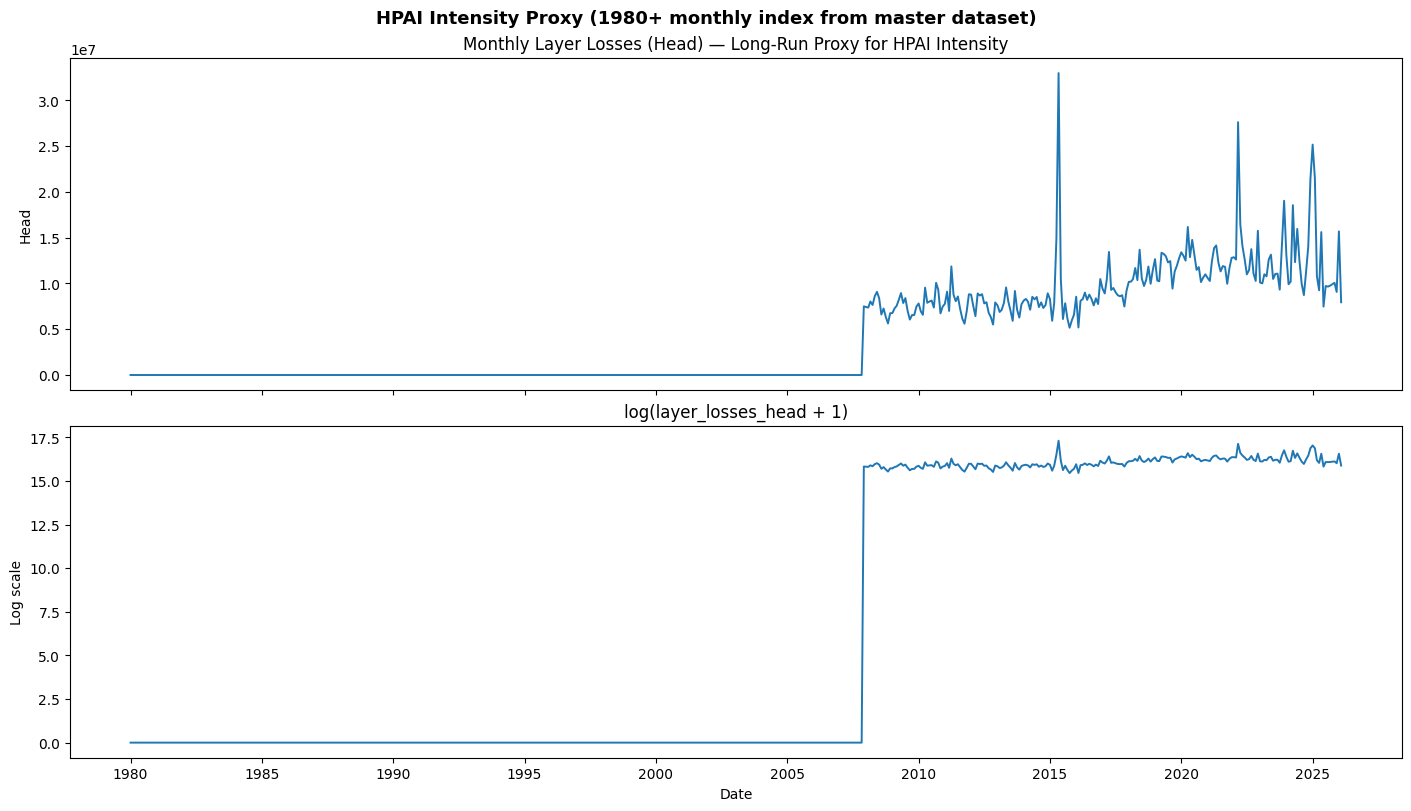


Saved plot:
/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data/hpai_intensity_proxy_1980plus_plot.png


In [ ]:
# ==========================================================
# Build long-run monthly HPAI-intensity proxy export
# Using avian_flu_master_dataset.csv
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ----------------------------------------------------------
# Paths
# ----------------------------------------------------------
base_dir = "/content/drive/Shareddrives/DS 440 Team 1/Avian Flu Covariate/data"
input_path = f"{base_dir}/avian_flu_master_dataset.csv"
save_csv_path = f"{base_dir}/hpai_intensity_proxy_1980plus.csv"
save_plot_path = f"{base_dir}/hpai_intensity_proxy_1980plus_plot.png"

# ----------------------------------------------------------
# Load master dataset
# ----------------------------------------------------------
master = pd.read_csv(input_path, parse_dates=["month"])

print("Loaded:", input_path)
print("Shape:", master.shape)
print("\nColumns:")
print(master.columns.tolist())

# ----------------------------------------------------------
# Check required columns
# ----------------------------------------------------------
required_cols = ["month", "layer_losses_head"]
missing = [c for c in required_cols if c not in master.columns]
if missing:
    raise ValueError(f"Missing required columns in master dataset: {missing}")

# ----------------------------------------------------------
# Build export
# ----------------------------------------------------------
export_cols = ["month", "layer_losses_head"]

# Keep optional helpful columns if present
optional_cols = ["outbreak_dummy", "severity_score", "hpai_birds_affected"]
for c in optional_cols:
    if c in master.columns:
        export_cols.append(c)

hpai_proxy = master[export_cols].copy()

# Rename month -> date
hpai_proxy = hpai_proxy.rename(columns={"month": "date"})

# Ensure monthly datetime
hpai_proxy["date"] = pd.to_datetime(hpai_proxy["date"]).dt.to_period("M").dt.to_timestamp()

# Fill missing losses with 0 for proxy construction
hpai_proxy["layer_losses_head"] = (
    pd.to_numeric(hpai_proxy["layer_losses_head"], errors="coerce")
    .fillna(0)
    .clip(lower=0)
)

# Main transformed variable
hpai_proxy["log_layer_losses_plus1"] = np.log(hpai_proxy["layer_losses_head"] + 1)

# Optional direct modern APHIS transform if present
if "hpai_birds_affected" in hpai_proxy.columns:
    hpai_proxy["hpai_birds_affected"] = (
        pd.to_numeric(hpai_proxy["hpai_birds_affected"], errors="coerce")
        .fillna(0)
        .clip(lower=0)
    )
    hpai_proxy["log_hpai_birds_affected_plus1"] = np.log(hpai_proxy["hpai_birds_affected"] + 1)

# Sort
hpai_proxy = hpai_proxy.sort_values("date").reset_index(drop=True)

# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------
os.makedirs(base_dir, exist_ok=True)
hpai_proxy.to_csv(save_csv_path, index=False)

print("\nSaved CSV:")
print(save_csv_path)

print("\nPreview:")
print(hpai_proxy.head(12))

print("\nDate range:")
print(hpai_proxy["date"].min(), "to", hpai_proxy["date"].max())

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)

# Raw layer losses
axes[0].plot(hpai_proxy["date"], hpai_proxy["layer_losses_head"], linewidth=1.4)
axes[0].set_title("Monthly Layer Losses (Head) — Long-Run Proxy for HPAI Intensity")
axes[0].set_ylabel("Head")

# Log-transformed proxy
axes[1].plot(hpai_proxy["date"], hpai_proxy["log_layer_losses_plus1"], linewidth=1.4)
axes[1].set_title("log(layer_losses_head + 1)")
axes[1].set_ylabel("Log scale")
axes[1].set_xlabel("Date")

axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("HPAI Intensity Proxy (1980+ monthly index from master dataset)", fontsize=13, fontweight="bold")
plt.savefig(save_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved plot:")
print(save_plot_path)